<a href="https://colab.research.google.com/github/Ayeesha2023/ECO-LENS-/blob/main/updated_dataset_with_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================================================================
# BULLETPROOF YOLOv8 TRAINING (LIVE-SAVE TO GOOGLE DRIVE)
# ======================================================================

# 1. Mount Google Drive
from google.colab import drive
import os
import yaml

print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define Paths
# Sourced from your Drive structure: MyDrive/ECO-LENS/Master_Set/
zip_path = "/content/drive/MyDrive/ECO-LENS/Master_Set/ECO-LENS MASTER SET.yolov8.zip"
extract_path = "/content/dataset"

# THIS IS YOUR VAULT: All weights and charts will save here live.
drive_save_dir = "/content/drive/MyDrive/ECO-LENS/Master_Set/YOLO_Outputs"
os.makedirs(drive_save_dir, exist_ok=True)

# 3. Extract Dataset to Local Colab Storage (Crucial for fast training speeds)
print("Unzipping dataset locally (this will take a moment)...")
!mkdir -p {extract_path}
!unzip -q -o "{zip_path}" -d {extract_path}

# 4. Update data.yaml with absolute Colab paths so YOLO doesn't get confused
print("Fixing data.yaml paths...")
yaml_path = os.path.join(extract_path, "data.yaml")
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = os.path.join(extract_path, 'train/images')
data['val'] = os.path.join(extract_path, 'valid/images')
if 'test' in data:
    data['test'] = os.path.join(extract_path, 'test/images')

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

# 5. Install Ultralytics quietly
print("Installing YOLOv8...")
!pip install ultralytics -q

# 6. TRAIN: Hardwired to Google Drive
from ultralytics import YOLO

# Upgrading to the medium model to break past your 65% mAP cap
model = YOLO('yolov8m.pt')

print(f"\n🚀 STARTING TRAINING. ALL FILES WILL LIVE-SAVE TO: {drive_save_dir}")

# The 'project' argument routes all outputs directly to your Drive.
results = model.train(
    data=yaml_path,
    epochs=100,              # Running 100 since your progress is now safe
    imgsz=640,
    project=drive_save_dir,  # <-- THE MAGIC BULLET
    name='eco_lens_run',     # Creates a folder named 'eco_lens_run' in YOLO_Outputs
    exist_ok=True            # Overwrites the folder cleanly if you restart
)

Mounting Google Drive...
Mounted at /content/drive
Unzipping dataset locally (this will take a moment)...
Fixing data.yaml paths...
Installing YOLOv8...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🚀 STARTING TRAINING. ALL FILES WILL LIVE-SAVE TO: /content/drive/MyDrive/ECO-LENS/Master_Set/YOLO_Outputs
Ultralytics 8.4.94 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, 

In [ ]:
#ramisa do not run this unless the 1st code cell suddenly stops running
#the instructions for this one is given here


# ======================================================================
# BULLETPROOF YOLOv8 RESUMPTION CELL (RUN ONLY AFTER A CRASH)
# ======================================================================

# 1. Mount Google Drive
from google.colab import drive
import os
import yaml

print("Re-mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define Paths (Must match your original paths exactly)
zip_path = "/content/drive/MyDrive/ECO-LENS/Master_Set/ECO-LENS MASTER SET.yolov8.zip"
extract_path = "/content/dataset"
last_weights_path = "/content/drive/MyDrive/ECO-LENS/Master_Set/YOLO_Outputs/eco_lens_run/weights/last.pt"

# 3. Verify the last checkpoint exists before doing anything
if not os.path.exists(last_weights_path):
    raise FileNotFoundError(f"🚨 Critical Error: Could not find 'last.pt' at {last_weights_path}. Check your Drive folder path!")

# 4. Re-Extract Dataset to Local Storage (Since the fresh VM is completely empty)
print("Re-unzipping dataset to fresh local environment...")
!mkdir -p {extract_path}
!unzip -q -o "{zip_path}" -d {extract_path}

# 5. Re-Fix data.yaml paths for the new environment
print("Verifying data.yaml paths...")
yaml_path = os.path.join(extract_path, "data.yaml")
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = os.path.join(extract_path, 'train/images')
data['val'] = os.path.join(extract_path, 'valid/images')
if 'test' in data:
    data['test'] = os.path.join(extract_path, 'test/images')

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

# 6. Re-install Ultralytics
print("Installing YOLOv8...")
!pip install ultralytics -q

# 7. RESUME TRAINING FROM CHECKPOINT
from ultralytics import YOLO

print(f"\n🔄 RESUMING TRAINING FROM: {last_weights_path}")

# Load the interrupted state directly from your Drive vault
model = YOLO(last_weights_path)

# Instruct YOLO to resume. It automatically reads the original configuration,
# target epoch count, and hyperparameters from the last.pt file.
results = model.train(resume=True)

Re-mounting Google Drive...
Mounted at /content/drive
Re-unzipping dataset to fresh local environment...
Verifying data.yaml paths...
Installing YOLOv8...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🔄 RESUMING TRAINING FROM: /content/drive/MyDrive/ECO-LENS/Master_Set/YOLO_Outputs/eco_lens_run/weights/last.pt
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cl

Mounting Google Drive...
Mounted at /content/drive

📈 Plotting current training trends...


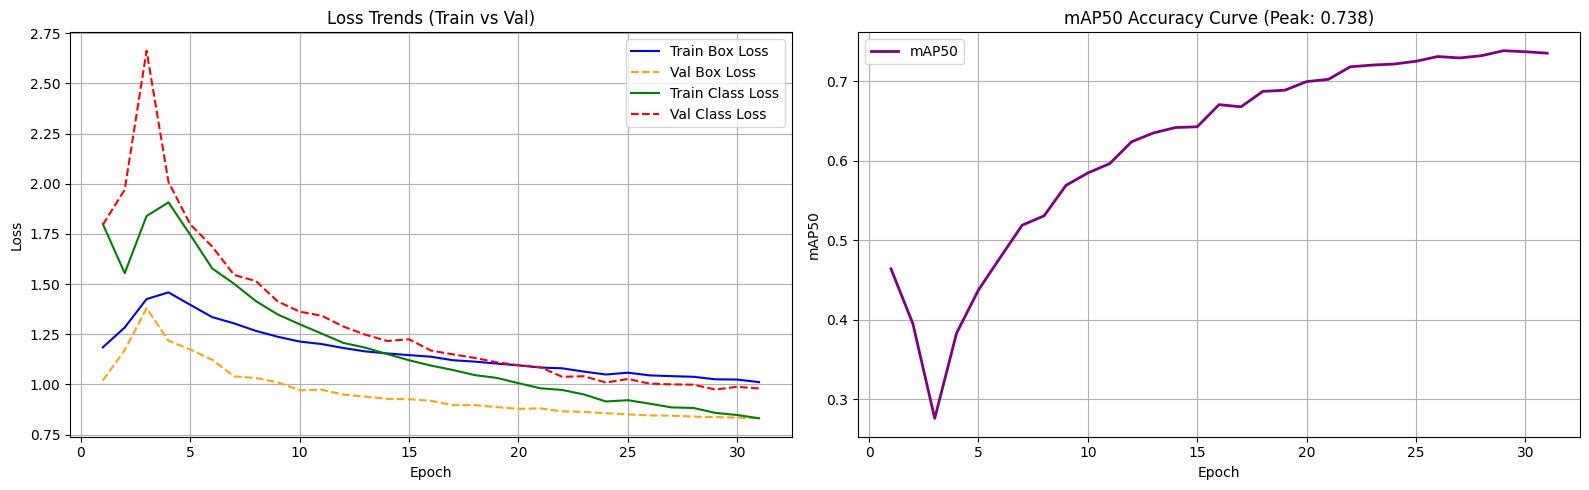

Current mAP50 (Epoch 31): 73.508%
Peak mAP50 Achieved: 73.820%

Dataset not found in local storage. Unzipping (takes a moment)...

Installing Ultralytics quietly...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

⚙️ Running Validation on CPU to save T4 Credits...
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 7.3±4.8 MB/s, 

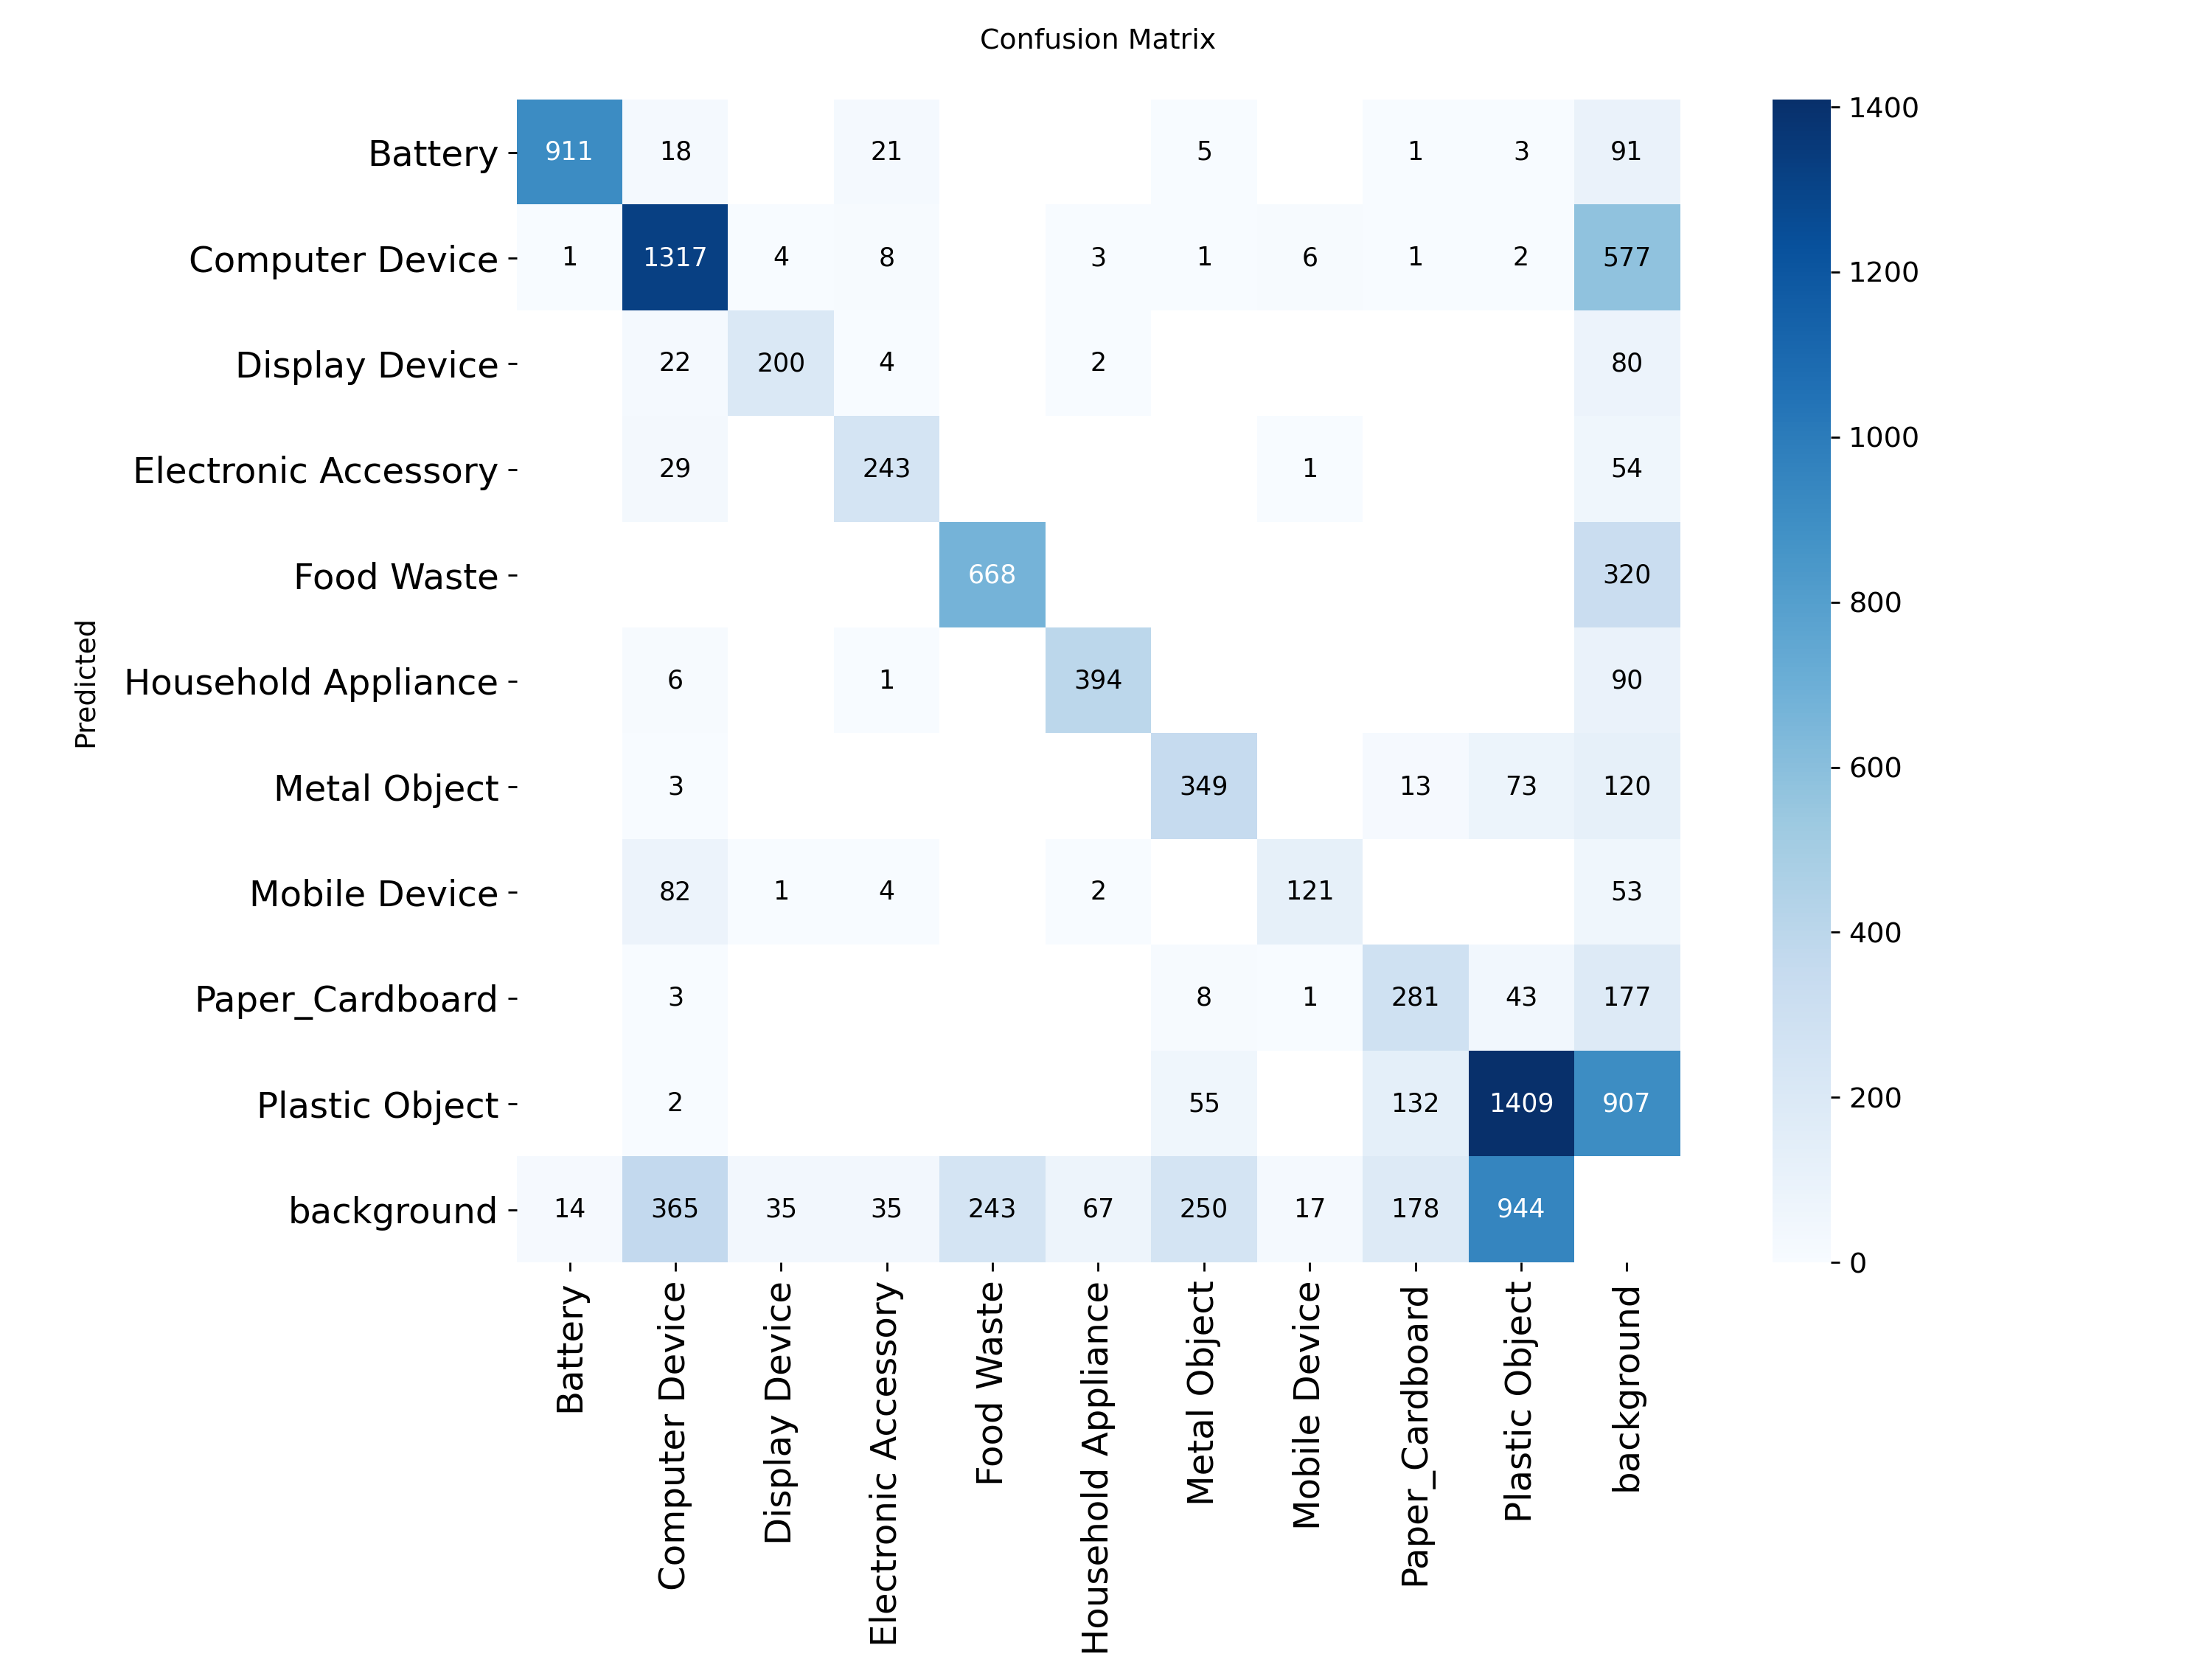


--- Validation Batch Predictions (val_batch0_pred.jpg) ---


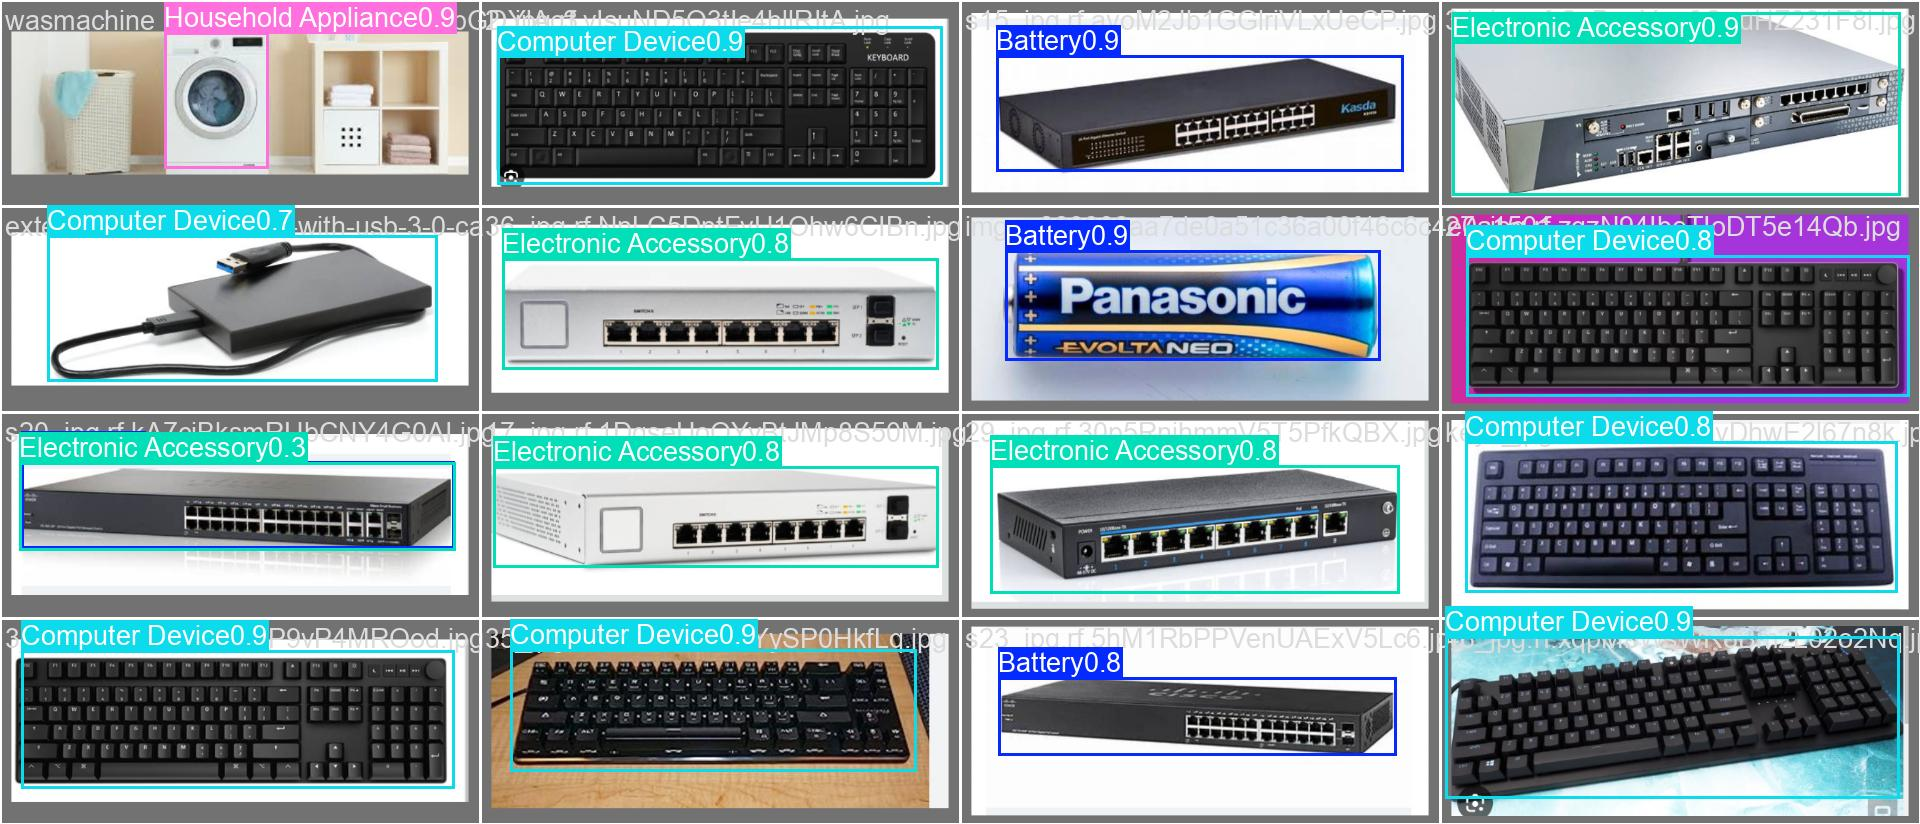

In [3]:
# ======================================================================
# MID-TRAINING RESULTS CHECKER & CPU VALIDATION RUNNER (STANDALONE)
# ======================================================================

# 1. Standalone Imports
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 2. Mount Google Drive (Ensures we can access your data safely)
print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 3. Define Directories and Paths
run_dir = "/content/drive/MyDrive/ECO-LENS/Master_Set/YOLO_Outputs/eco_lens_run"
results_csv = os.path.join(run_dir, "results.csv")
last_weights_path = os.path.join(run_dir, "weights/last.pt")

# 4. Step 1: Plot the metrics from results.csv if it exists
if os.path.exists(results_csv):
    print("\n📈 Plotting current training trends...")
    df = pd.read_csv(results_csv)
    # Strip whitespace from columns
    df.columns = df.columns.str.strip()

    epochs = df['epoch']

    plt.figure(figsize=(16, 5))

    # Left subplot: Losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, df['train/box_loss'], label='Train Box Loss', color='blue')
    plt.plot(epochs, df['val/box_loss'], label='Val Box Loss', color='orange', linestyle='--')
    plt.plot(epochs, df['train/cls_loss'], label='Train Class Loss', color='green')
    plt.plot(epochs, df['val/cls_loss'], label='Val Class Loss', color='red', linestyle='--')
    plt.title('Loss Trends (Train vs Val)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Right subplot: mAP50 Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, df['metrics/mAP50(B)'], label='mAP50', color='purple', linewidth=2)
    plt.title(f'mAP50 Accuracy Curve (Peak: {df["metrics/mAP50(B)"].max():.3f})')
    plt.xlabel('Epoch')
    plt.ylabel('mAP50')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Quick printed diagnosis
    current_map = df['metrics/mAP50(B)'].iloc[-1]
    peak_map = df['metrics/mAP50(B)'].max()
    print(f"Current mAP50 (Epoch {epochs.iloc[-1]}): {current_map:.3%}")
    print(f"Peak mAP50 Achieved: {peak_map:.3%}")
else:
    print(f"⚠️ Warning: Could not find results.csv at {results_csv}. Skipping graph generation.")

# 5. Step 2: Ensure Dataset is Unzipped in Local Colab Storage
zip_path = "/content/drive/MyDrive/ECO-LENS/Master_Set/ECO-LENS MASTER SET.yolov8.zip"
extract_path = "/content/dataset"
yaml_path = os.path.join(extract_path, "data.yaml")

if not os.path.exists(yaml_path):
    print("\nDataset not found in local storage. Unzipping (takes a moment)...")
    os.makedirs(extract_path, exist_ok=True)
    !unzip -q -o "{zip_path}" -d {extract_path}

    # Re-write absolute paths so YOLO doesn't fail
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    data['train'] = os.path.join(extract_path, 'train/images')
    data['val'] = os.path.join(extract_path, 'valid/images')
    if 'test' in data:
        data['test'] = os.path.join(extract_path, 'test/images')
    with open(yaml_path, 'w') as f:
        yaml.dump(data, f)
else:
    print("\nDataset already unzipped. Proceeding...")

# 6. Step 3: Run CPU-only Validation to generate Confusion Matrix
eval_dir = "/content/drive/MyDrive/ECO-LENS/Master_Set/YOLO_Outputs"
eval_name = "eco_lens_midway_eval"

if os.path.exists(last_weights_path):
    print("\nInstalling Ultralytics quietly...")
    !pip install ultralytics -q
    from ultralytics import YOLO

    print("\n⚙️ Running Validation on CPU to save T4 Credits...")
    model = YOLO(last_weights_path)

    # Force YOLOv8 to run metrics validation strictly on CPU
    metrics = model.val(
        data=yaml_path,
        project=eval_dir,
        name=eval_name,
        device='cpu',       # <-- FORCES CPU ONLY
        exist_ok=True
    )

    # 7. Step 4: Display Generated Visuals
    print("\n" + "="*80)
    print("🖼️ DISPLAYING MID-TRAINING VISUALS:")
    print("="*80)

    generated_folder = os.path.join(eval_dir, eval_name)
    visual_files = [
        ("Confusion Matrix", "confusion_matrix.png"),
        ("Validation Batch Predictions", "val_batch0_pred.jpg")
    ]

    for title, filename in visual_files:
        file_path = os.path.join(generated_folder, filename)
        if os.path.exists(file_path):
            print(f"\n--- {title} ({filename}) ---")
            display(Image(filename=file_path, width=800))
        else:
            print(f"⚠️ Could not find {filename} in {generated_folder}")
else:
    print(f"\n🚨 Error: Could not find model weights at {last_weights_path}")

In [ ]:
# ======================================================================
# YOLOv8 TARGETED RESUMPTION CELL (RUN NEXT 20 EPOCHS ONLY)
# ======================================================================

# 1. Standalone Imports
import os
import yaml
import pandas as pd

# 2. Mount Google Drive
print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 3. Define Paths
zip_path = "/content/drive/MyDrive/ECO-LENS/Master_Set/ECO-LENS MASTER SET.yolov8.zip"
extract_path = "/content/dataset"
run_dir = "/content/drive/MyDrive/ECO-LENS/Master_Set/YOLO_Outputs/eco_lens_run"
last_weights_path = os.path.join(run_dir, "weights/last.pt")
args_yaml_path = os.path.join(run_dir, "args.yaml")
results_csv_path = os.path.join(run_dir, "results.csv")

# 4. Verify original checkpoint weights exist
if not os.path.exists(last_weights_path):
    raise FileNotFoundError(f"🚨 Error: Could not find last.pt at {last_weights_path}!")

# 5. Extract Dataset to Local Storage (In case Colab refreshed your runtime)
yaml_path = os.path.join(extract_path, "data.yaml")
if not os.path.exists(yaml_path):
    print("\nDataset not found in local storage. Unzipping (this takes a moment)...")
    os.makedirs(extract_path, exist_ok=True)
    os.system(f'unzip -q -o "{zip_path}" -d {extract_path}')

    # Correct YAML paths for local environment
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    data['train'] = os.path.join(extract_path, 'train/images')
    data['val'] = os.path.join(extract_path, 'valid/images')
    if 'test' in data:
        data['test'] = os.path.join(extract_path, 'test/images')
    with open(yaml_path, 'w') as f:
        yaml.dump(data, f)
else:
    print("\nDataset already unzipped. Proceeding...")

# 6. Adjust YOLOv8 target epoch limit dynamically
current_epoch = 0
if os.path.exists(results_csv_path):
    try:
        df = pd.read_csv(results_csv_path)
        df.columns = df.columns.str.strip()
        current_epoch = int(df['epoch'].iloc[-1])
        print(f"\n📈 Detected last completed epoch: {current_epoch}")
    except Exception as e:
        print(f"⚠️ Warning reading results.csv: {e}. Defaulting to Epoch 31 estimation.")
        current_epoch = 31
else:
    current_epoch = 31

new_target_epoch = current_epoch + 20
print(f"🎯 Changing total training target to {new_target_epoch} epochs (adding exactly 20 epochs)...")

# Overwrite YOLOv8 configuration directly in your Drive folder
if os.path.exists(args_yaml_path):
    with open(args_yaml_path, 'r') as f:
        args_data = yaml.safe_load(f)

    args_data['epochs'] = new_target_epoch

    with open(args_yaml_path, 'w') as f:
        yaml.dump(args_data, f, default_flow_style=False)
    print("✅ Configuration updated successfully.")
else:
    print(f"⚠️ Warning: args.yaml not found at {args_yaml_path}. Resuming using default parameters.")

# 7. Install Ultralytics and resume training on GPU
print("\nInstalling Ultralytics quietly...")
os.system('pip install ultralytics -q')
from ultralytics import YOLO

print(f"\n🔄 RESUMING TRAINING ON GPU UP TO EPOCH {new_target_epoch}...")
model = YOLO(last_weights_path)

# Resume command reads your adjusted args.yaml and finishes exactly at the target epoch
results = model.train(resume=True)

Mounting Google Drive...
Mounted at /content/drive

Dataset not found in local storage. Unzipping (this takes a moment)...

📈 Detected last completed epoch: 31
🎯 Changing total training target to 51 epochs (adding exactly 20 epochs)...
✅ Configuration updated successfully.

Installing Ultralytics quietly...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🔄 RESUMING TRAINING ON GPU UP TO EPOCH 51...
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_pas